# Creating a Lightcurve using a TESS FFI downloaded from MAST
## Author
Aidan Niklaus

## Learning Goals
- Become familiar with Lightkurve basics
- Become familiar with the Mikulski Archive for Space Telescopes (MAST)
- Search for and download TESS Full Frame Images (FFI) from MAST
- Create and plot a Lightcurve from a FFI
- Use aperture masking to create a TPF from an FFI, create a lightcurve from a TPF, and filter out background noise
- Perform arithmetic on Lightcurves

## Keywords
TESS, MAST, TPF, FFI, Lightcurve, aperture masking, TGLC

## Summary
This tutorial will demonstrate how to utilize the Python package Lightkurve in tandem with MAST to create a lightcurve using a TESS FFI.

## Imports

In [2]:
import lightkurve as lk

# Makes plots appear directly after respective code block
%matplotlib inline

## Step 1: Search for the FFI
In the previous tutorial, our search for a TPF of TIC 408036613 came up empty---but no matter---we can instead pull from MAST a TESS Full Frame Image (FFI), then from that make our own TPF!

Let's search for that FFI.

In [4]:
# target : the name or identifying number of your star
search_result = lk.search_tesscut(target="TIC 408036613")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 03,2018,TESScut,1426,TIC 408036613,0.0
1,TESS Sector 30,2020,TESScut,475,TIC 408036613,0.0
2,TESS Sector 97,2025,TESScut,158,TIC 408036613,0.0


Great! It looks like we have three FFIs to choose from. While we could download them all at once, let's instead work with just the first one for this example (0th index), as this will reduce the computation required to execute the task. This is important because downloading files from MAST is the most computationally expensive aspect of creating a lightcurve, so alleviating some of that stress is always helpful.

## Step 2: Download the FFI as a TPF

Think of TPFs as a cropped FFI centered on our star. Therefore, in order to go from the FFI we have to the TPF we want, we simply must tell Lightkurve the crop size we want. We can do this in the download process.

In [8]:
# cutout_size : specifies the TPF size ("cropped" from the FFI), in this example, we asked for a 20x20 pixel TPF
tpf = search_result[0].download(cutout_size=20)

It is always good practice to get visual confirmation of the data we are working with. Let's plot the TPF we just made from our FFI to check it out.

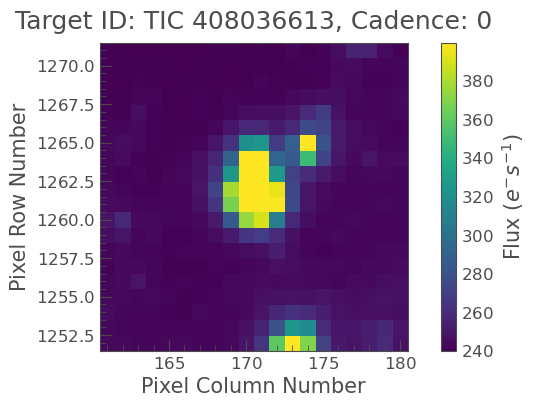

In [9]:
tpf.plot();

## Step 3: Use Aperture Masking to Define Star Pixels

Cool! As you can see, the high-flux, yellow parts of the graph are our star, with the dimmer parts being the background. Despite this distinction being very obvious to our eyes, our program still doesn't know what parts of the TPF to graph. To solve this, we can use a method called aperture masking to define to Lightkurve what is and isn't our star.

In [18]:
# Higher thresholds are more selective as they increase the "passing" value for pixels
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')

Aperture masking works by only grabbing pixels that surpass a certain threshold. Let's check that the threshold we set is accurate by graphing our TPF again, but this time with the aperture mask over it.

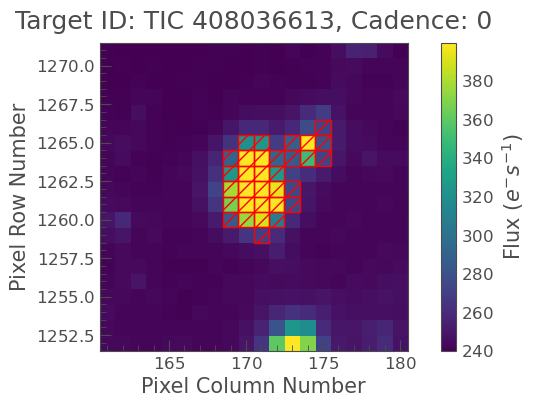

In [19]:
tpf.plot(aperture_mask=target_mask);

## Step 4: Plot the Lightcurve

Great! Now our computer can see what our eyes see! Let's now use our TPF along with that mask to make our lightcurve.

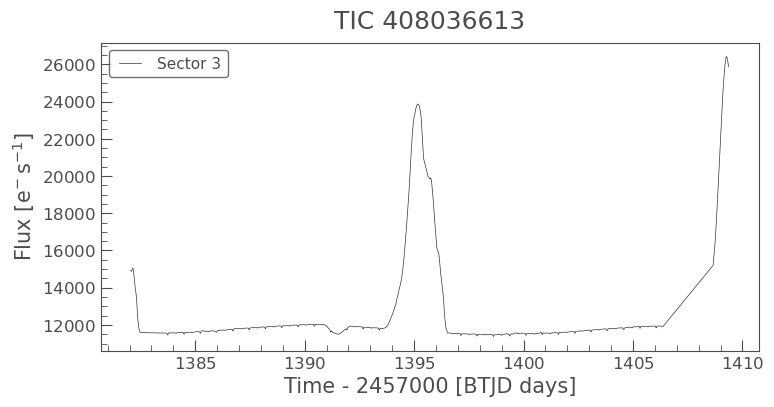

In [20]:
# Making sure to let Lightkurve know that we just want to use the pixels within our mask to make our lightcurve
lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Plotting our lightcurve to see what we got!
lc.plot(title="TIC 408036613", label="Sector 3");

## Step 4: Cleanup

Sometimes your lightcurve will come out looking great; and if that is the case for you, great job, you're done! More frequently however, we need to filter out background noise in order for the actual astrophysical signal to shine through. In this example, there are very faint dips along the bottom sections of the curve---this is what we actually want. The other spikes are more likely than not spacecraft-induced noise we can filter out using background masking.

#### 4.1: Background Masking

Background masking is the same aperture masking process we used to find our star pixels, except now applied to the low-flux areas around the star. If we are able to find how much flux is emitted from these background pixels, then we have a good estimation of the amount of noise present in our TPF. By subtracting that noise from our star pixels, we can effectively plot just the astrophysical signal we are aiming for.

Let's start by creating the background mask and plotting it on top of our TPF to check it's accuracy.

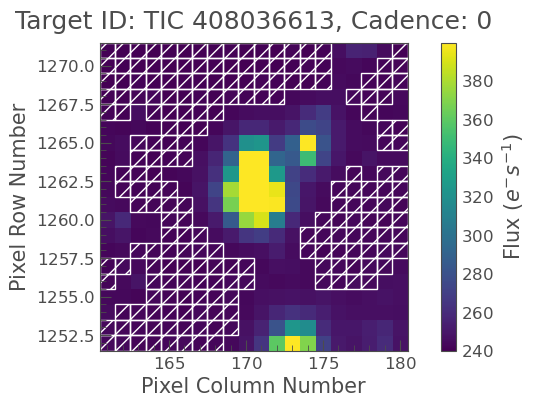

In [22]:
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

tpf.plot(aperture_mask=background_mask, mask_color='white');

#### 4.2: Finding Noise Per Pixel

Looks pretty good, but there is one more intermediate step we need to take before plotting another lightcurve using these background pixels.

At the moment we would be plotting the flux over time; but we need to plot flux per pixel over time. That way we can apply it to each pixel in our target mask. We can do this by dividing the lightcurve of our background mask by the total number of pixels in said mask, leaving us with a lightcurve representing the flux per pixel over time emitted by the background of our TPF. In other words, an estimation of how much noise is present in each pixel of our TPF.

In [23]:
# Grabbing the amount of pixels in our background mask
n_background_pixels = background_mask.sum()
n_background_pixels

np.int64(201)

In [25]:
# Must first make a lightcurve from our background mask, then can divide it by the amount of pixels in that mask to get our average noise per pixel lightcurve
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask) / n_background_pixels)

#### 4.3: Finding Total Noise in Target Mask

Now that we have a lightcurve representing the amount of noise present in each pixel of our our TPF, we can multiply it by the number of pixels in our target mask to find an approximation of how much noise is present throughout our star pixels. This is the lightcurve we can finally plot and subtract from our original to find the true signal of our star.

In [26]:
# Grabbing the amount of pixels in our target mask
n_target_pixels = target_mask.sum()
n_target_pixels

np.int64(32)

In [28]:
# Multiplying our average noise per pixel lightcurve by the amount of pixels in our target mask to find a lightcurve representing the total noise present in our star pixels
noise_lc = background_lc_per_pixel * n_target_pixels

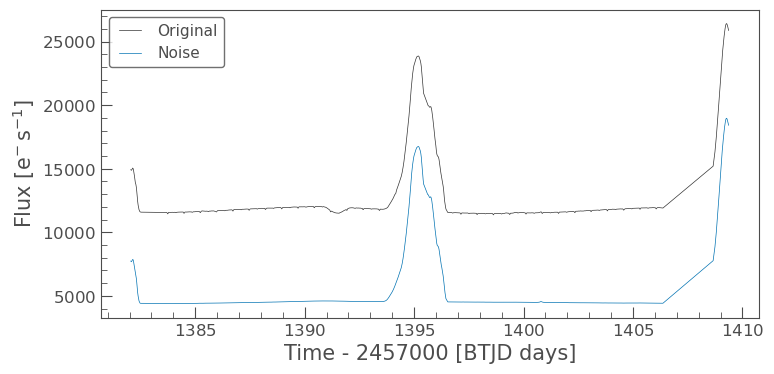

In [31]:
# Plotting both the original and noise lightcurves for visual confirmation
ax = lc.plot(label = "Original");
noise_lc.plot(ax=ax, label="Noise");
# Note: may need to use common normalization to properly see both curves

#### 4.4: Correcting the Original Lightcurve

Looks promising! Those spikes do indeed seem to be caused by noise. Let's subtract the noise out from the original and see the lightcurve we get.

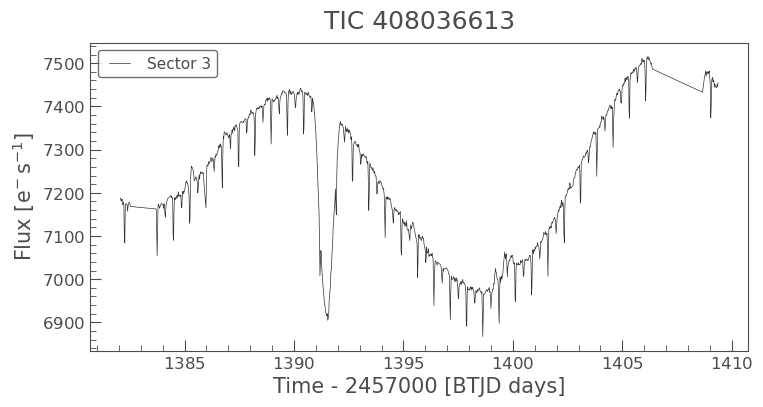

In [35]:
# Subtracting the noise lightcurve from the original lightcurve to get our corrected lightcurve
corrected_lc = lc - noise_lc

# Plotting our corrected light curve to see what we got!
corrected_lc.plot(title="TIC 408036613", label="Sector 3");

#### 4.5: More Cleaning?

In this example, we pulled a beautiful Eclipsing Binary. No more cleaning is necessary. However, this may not always be the case. There are tools such as TESS-GAIA Light Curve (TGLC) we can use to further denoise our lightcurves. Click HERE to continue to that tutorial.

## Workflow Recap

A clean lightcurve can tell us a lot about the nature of stars as they clearly show the amount of light emitted over time. Keyword: clean; and as shown in this tutorial, the cleaning process can be the biggest challenge. Below is a recap of the workflow we used to overcome it:
1. search MAST for available FFIs of our star
2. download one "cropped" FFI to use as a TPF
3. make an aperture mask that captures only our star pixels
4. make an initial light curve using our TPF and mask
5. analyze your lightcurve for cleaning
6. if needs cleaning, start by making an aperture mask of the background pixels
7. find the average flux per background pixel (noise)
8. remove that noise from our star pixels, resulting in the corrected light curve
9. plot corrected light curve and reanalyze for further cleaning (TGLC if yes)